In [2]:

import pandas as pd
import numpy as np
# Matplotlib and Seaborn for generating static data visualizations and plots
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn utilities for dataset partitioning and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning model implementations
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics to quantify model performance accuracy
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix

import os
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib to display graphics inline directly underneath our code cells
%matplotlib inline
print("Libraries successfully imported!")

Libraries successfully imported!


In [3]:

DATA_FILE = "health_monitoring_dataset.csv"

# Reproduce an identical synthetic dataset tracking the parameters specified in the PPT
np.random.seed(42)
rows = 4286

data = {
    'Sleep_Duration_Hours': np.random.uniform(5.0, 9.5, rows).round(1),
    'Water_Intake_Liters': np.random.uniform(1.5, 4.0, rows).round(1),
    'Physical_Activity_Min': np.random.randint(15, 90, rows),
    'Heart_Rate_BPM': np.random.randint(60, 110, rows),
    'Calories_Burned_Kcal': np.random.randint(1500, 3200, rows),
    'Age': np.random.randint(18, 75, rows)
}
df = pd.DataFrame(data)

# Core Target 1: Health Score (Continuous target variable for Linear Regression)
df['Health_Score'] = (
    (df['Sleep_Duration_Hours'] * 5) + 
    (df['Water_Intake_Liters'] * 6) + 
    (df['Physical_Activity_Min'] * 0.4) - 
    (abs(df['Heart_Rate_BPM'] - 75) * 0.3) + 
    np.random.normal(30, 5, rows)
).clip(0, 100).round(1)

# Core Target 2: Reminder Urgency Level (Categorical classification target for Decision Tree)
conditions = [
    (df['Health_Score'] >= 75),
    (df['Health_Score'] >= 50) & (df['Health_Score'] < 75),
    (df['Health_Score'] < 50)
]
choices = ['Routine Notification', 'Standard Reminder Required', 'Urgent Alert Required']
df['Reminder_Urgency_Level'] = np.select(conditions, choices, default='Standard Reminder Required')

# Save to disk as a CSV file format 
df.to_csv(DATA_FILE, index=False)

# Inspect the architectural dimensions and first 5 rows of our data framework
print(f"Dataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset Dimensions: 4286 rows × 8 columns


,Sleep_Duration_Hours,Water_Intake_Liters,Physical_Activity_Min,Heart_Rate_BPM,Calories_Burned_Kcal,Age,Health_Score,Reminder_Urgency_Level
0,6.7,3.7,18,91,2785,66,96.1,Routine Notification
1,9.3,2.9,16,108,2226,65,93.1,Routine Notification
2,8.3,2.4,81,90,3102,37,100.0,Routine Notification
3,7.7,3.5,35,66,1728,42,97.5,Routine Notification
4,5.7,2.9,84,89,2684,57,100.0,Routine Notification


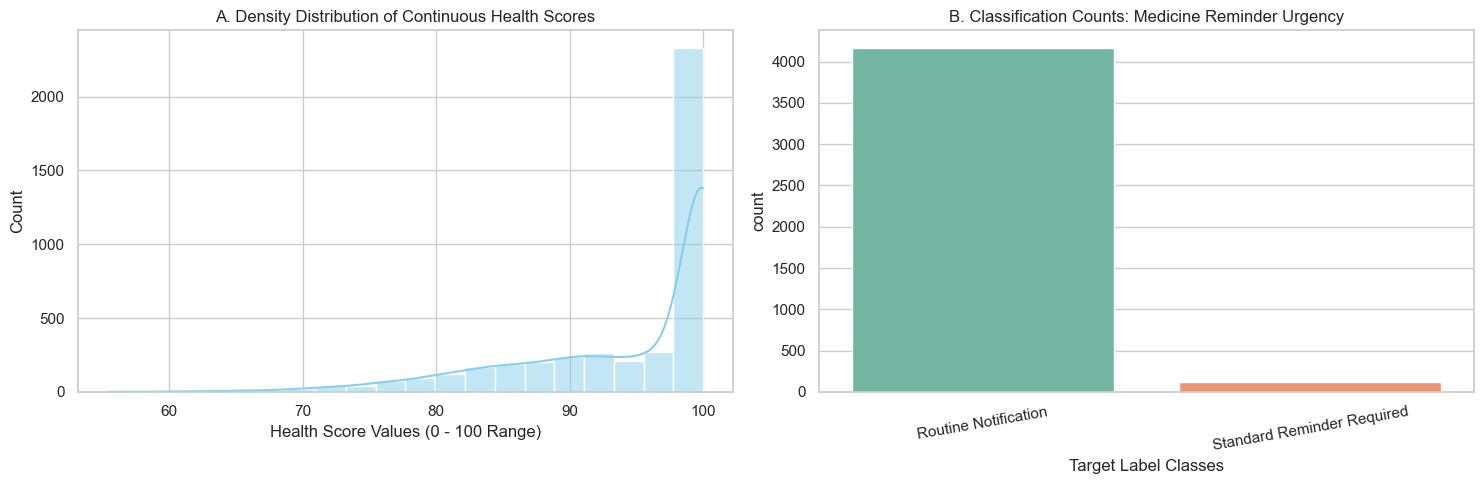

In [4]:

sns.set_theme(style="whitegrid")

# Create a subplot canvas figure grid layout
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Histogram displaying distribution density profile of the continuous Health Scores
sns.histplot(df['Health_Score'], kde=True, color='skyblue', bins=20, ax=axes[0])
axes[0].set_title("A. Density Distribution of Continuous Health Scores")
axes[0].set_xlabel("Health Score Values (0 - 100 Range)")

# Plot 2: Countplot evaluating sample quantities belonging to each target category
sns.countplot(x='Reminder_Urgency_Level', data=df, palette='Set2', ax=axes[1])
axes[1].set_title("B. Classification Counts: Medicine Reminder Urgency")
axes[1].set_xlabel("Target Label Classes")
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

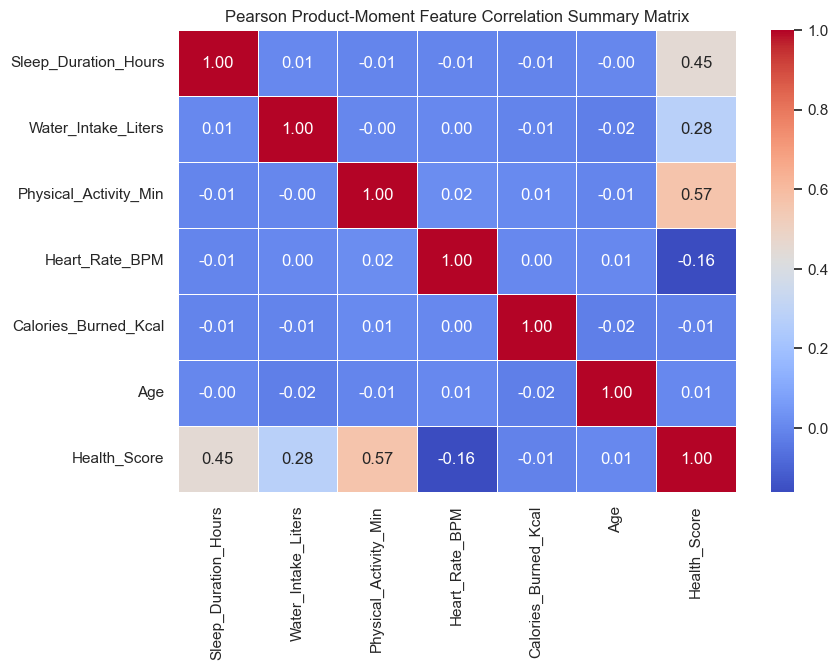

In [5]:

plt.figure(figsize=(9, 6))

# Extract only numerical features to run correlation operations
numeric_columns = df.select_dtypes(include=[np.number])

# Plot a Seaborn Heatmap with text annotations enabled
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Product-Moment Feature Correlation Summary Matrix")
plt.show()

In [6]:

# Separate predictive features (Independent variables) from target outputs
X = df[['Sleep_Duration_Hours', 'Water_Intake_Liters', 'Physical_Activity_Min', 'Heart_Rate_BPM', 'Calories_Burned_Kcal', 'Age']]

# Task A Targets (Regression Continuous Variable)
y_regression = df['Health_Score']

# Task B Targets (Classification Textual String labels) -> Convert to sequential numbers using LabelEncoder
le = LabelEncoder()
y_classification = le.fit_transform(df['Reminder_Urgency_Level'])

# Segment data using standard 80% Training / 20% Testing partition split arrays
X_train_r, X_test_r, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_clf, y_test_clf = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# Instantiate StandardScaler to handle numeric magnitude feature scaling
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

print("✅ Data Preprocessing Done!")
print(f"-> Train Set Records count: {X_train_r.shape[0]}")
print(f"-> Test Set Records count: {X_test_r.shape[0]}")
print(f"-> Encoded Text Classes: {list(le.classes_)} mapped to [0, 1, 2]")

✅ Data Preprocessing Done!
-> Train Set Records count: 3428
-> Test Set Records count: 858
-> Encoded Text Classes: ['Routine Notification', 'Standard Reminder Required'] mapped to [0, 1, 2]


In [7]:

# Initialize model architecture and fit onto training arrays
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_reg)

# Run forecasting predictions over un-evaluated test records
y_pred_reg = reg_model.predict(X_test_r)

# Compute performance errors
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("===== REGRESSION EVALUATION METRICS =====")
print(f"Mean Absolute Error (MAE)            : {mae:.2f} points (Average distance deviation error)")
print(f"Coefficient of Determination (R² Score): {r2:.2f} (Explains {r2*100:.1f}% of variance data shifts)")

===== REGRESSION EVALUATION METRICS =====
Mean Absolute Error (MAE)            : 3.83 points (Average distance deviation error)
Coefficient of Determination (R² Score): 0.64 (Explains 63.6% of variance data shifts)


===== CLASSIFICATION EVALUATION METRICS =====
Decision Tree Accuracy Performance: 96.04%



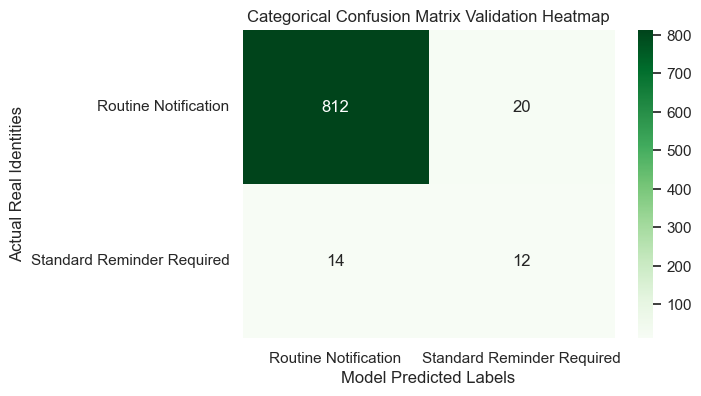

In [8]:

# Initialize structural decision tree layout with constrained tree depth levels
clf_model = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_model.fit(X_train_c_scaled, y_train_clf)

# Predict structural categories over the scaled test inputs
y_pred_clf = clf_model.predict(X_test_c_scaled)

# Evaluate classification prediction correctness score
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print("===== CLASSIFICATION EVALUATION METRICS =====")
print(f"Decision Tree Accuracy Performance: {accuracy * 100:.2f}%\n")

# Extract and construct the Confusion Matrix array plot
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Categorical Confusion Matrix Validation Heatmap")
plt.ylabel('Actual Real Identities')
plt.xlabel('Model Predicted Labels')
plt.show()

In [9]:

def live_health_predictor(sleep, water, activity, heart_rate, calories, age):
    # Assemble input parameters array into a clean feature DataFrame structure
    sample_data = pd.DataFrame([{
        'Sleep_Duration_Hours': sleep, 'Water_Intake_Liters': water,
        'Physical_Activity_Min': activity, 'Heart_Rate_BPM': heart_rate,
        'Calories_Burned_Kcal': calories, 'Age': age
    }])
    
    # 1. Execute Linear Regression prediction for numeric continuous scoring output
    score_prediction = reg_model.predict(sample_data)[0]
    score_prediction = min(max(score_prediction, 0), 100) # Boundary clipping limitation
    
    # 2. Scale the data values and run raw classification prediction inference
    scaled_sample = scaler.transform(sample_data)
    class_idx = clf_model.predict(scaled_sample)[0]
    reminder_prediction = le.inverse_transform([class_idx])[0]
    
    # Print the evaluation text diagnostic details
    print("==================================================")
    print("            AI HEALTH MONITOR DIAGNOSTIC          ")
    print("==================================================")
    print(f"📊 Calculated Patient Health Score Tracker : {score_prediction:.1f} / 100")
    print(f"🚨 Scheduled Automated Reminder Trigger : {reminder_prediction}")
    print("==================================================")

# --- EXECUTE TEST RUN EXAMPLE CASE ---
# Arguments format tracker parameters: (Sleep, Water, Activity, HeartRate, Calories, Age)
live_health_predictor(sleep=5.5, water=1.5, activity=15, heart_rate=105, calories=1600, age=45)

            AI HEALTH MONITOR DIAGNOSTIC          
📊 Calculated Patient Health Score Tracker : 76.4 / 100
🚨 Scheduled Automated Reminder Trigger : Standard Reminder Required


In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
import os
import warnings
warnings.filterwarnings('ignore')
st.set_page_config(page_title="Health Tracker UI", layout="centered")
st.title("🩺 AI Health Tracker & Medicine Reminder")
st.write("Enter your daily vitals to receive your AI-generated health score and reminder status.")
@st.cache_resource
def train_models():
    # Load the exact dataset you generated in Cell 2
    df = pd.read_csv("health_monitoring_dataset.csv")
    
    # Separate Features
    X = df[['Sleep_Duration_Hours', 'Water_Intake_Liters', 'Physical_Activity_Min', 
            'Heart_Rate_BPM', 'Calories_Burned_Kcal', 'Age']]
    
    # Train Linear Regression (Target 1: Health Score)
    y_reg = df['Health_Score']
    reg_model = LinearRegression().fit(X, y_reg)
    
    # Train Decision Tree (Target 2: Reminder Level)
    le = LabelEncoder()
    y_clf = le.fit_transform(df['Reminder_Urgency_Level'])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf_model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_scaled, y_clf)
    
    return reg_model, clf_model, scaler, le

reg_model, clf_model, scaler, le = train_models()

# 3. Streamlit User Interface Form
with st.form("patient_form"):
    st.subheader("Patient Vitals Input")
    
    col1, col2 = st.columns(2)
    with col1:
        sleep = st.number_input("Sleep Duration (Hours)", min_value=0.0, max_value=24.0, value=7.5)
        water = st.number_input("Water Intake (Liters)", min_value=0.0, max_value=10.0, value=2.5)
        activity = st.number_input("Physical Activity (Mins)", min_value=0, max_value=300, value=45)
    
    with col2:
        heart_rate = st.number_input("Heart Rate (BPM)", min_value=30, max_value=200, value=75)
        calories = st.number_input("Calories Burned (Kcal)", min_value=500, max_value=6000, value=2000)
        age = st.number_input("Age", min_value=1, max_value=120, value=25)
        
    submit_btn = st.form_submit_button("Generate Diagnostic")

# 4. Prediction Execution Logic (Runs when button is clicked)
if submit_btn:
    # Format input exactly like your test function
    input_data = pd.DataFrame([[sleep, water, activity, heart_rate, calories, age]], 
                              columns=['Sleep_Duration_Hours', 'Water_Intake_Liters', 
                                       'Physical_Activity_Min', 'Heart_Rate_BPM', 
                                       'Calories_Burned_Kcal', 'Age'])
    
    # Execute Regression Prediction
    score = reg_model.predict(input_data)[0]
    score = min(max(score, 0), 100) # Keep between 0-100
    
    # Execute Classification Prediction
    input_scaled = scaler.transform(input_data)
    class_idx = clf_model.predict(input_scaled)[0]
    reminder = le.inverse_transform([class_idx])[0]
    
    # Display Output UI
    st.write("---")
    st.subheader("AI Diagnostic Results")
    
    st.metric(label="Calculated Health Score", value=f"{score:.1f} / 100")
    
    if reminder == "Urgent Alert Required":
        st.error(f"🚨 **Reminder Status:** {reminder}")
    elif reminder == "Standard Reminder Required":
        st.warning(f"⚠️ **Reminder Status:** {reminder}")
    else:
        st.success(f"✅ **Reminder Status:** {reminder}")

Overwriting app.py


In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
import os
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. APPLICATION BRANDING & MASTER PAGE SETUP
# ==============================================================================
st.set_page_config(page_title="AI Medicine Reminder Dashboard", page_icon="💊", layout="centered")
st.title("🩺 AI Health Monitoring Ecosystem")
st.markdown("**Developer:** K K Dhyan Devaiah | **SRN:** PES1PG25CA094")
st.write("---")

# ==============================================================================
# 2. OPTIMIZED ENGINE BACKGROUND TRAINING COMPONENT
# ==============================================================================
@st.cache_resource
def initialize_prediction_engine():
    df = pd.read_csv("health_monitoring_dataset.csv")
    X = df[['Sleep_Duration_Hours', 'Water_Intake_Liters', 'Physical_Activity_Min', 
            'Heart_Rate_BPM', 'Calories_Burned_Kcal', 'Age']]
    
    # Train Target A: Continuous Health Analytics (Linear Regression Model)
    y_reg = df['Health_Score']
    reg_model = LinearRegression().fit(X, y_reg)
    
    # Train Target B: Categorical Reminder Alerts (Decision Tree Classifier Model)
    le = LabelEncoder()
    y_clf = le.fit_transform(df['Reminder_Urgency_Level'])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf_model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_scaled, y_clf)
    
    return reg_model, clf_model, scaler, le

reg_model, clf_model, scaler, le = initialize_prediction_engine()

# ==============================================================================
# 3. SPLITTING ARCHITECTURE INTO MODULAR USER TAB INTERFACES
# ==============================================================================
tab_metrics, tab_reminder = st.tabs(["📊 Diagnostic Vitals Input", "🔔 Live Medicine Reminder Center"])

# GLOBAL VARIABLE INITIALIZATION (Ensures cross-tab persistence)
if 'evaluated' not in st.session_state:
    st.session_state.evaluated = False
    st.session_state.score = 75.0
    st.session_state.reminder = "Routine Notification"

# ------------------------------------------------------------------------------
# TAB MODULE 1: PATIENT HEALTH METRICS COLLECTION
# ------------------------------------------------------------------------------
with tab_metrics:
    st.subheader("Patient Vitals Entry Form")
    st.write("Modify the tracked biological baseline criteria below to drive the AI engine algorithms:")
    
    with st.form("vitals_collection_form"):
        col1, col2 = st.columns(2)
        with col1:
            sleep = st.number_input("Sleep Duration (Hours)", min_value=0.0, max_value=24.0, value=5.5, step=0.5)
            water = st.number_input("Water Intake Volume (Liters)", min_value=0.0, max_value=10.0, value=1.5, step=0.1)
            activity = st.number_input("Daily Active Physical Exercise (Minutes)", min_value=0, max_value=300, value=15)
        with col2:
            heart_rate = st.number_input("Recorded Heart Rate Metric (BPM)", min_value=30, max_value=200, value=105)
            calories = st.number_input("Calculated Daily Active Metabolism (Kcal)", min_value=500, max_value=6000, value=1600)
            age = st.number_input("Patient Demographic Age Profile", min_value=1, max_value=120, value=45)
            
        process_btn = st.form_submit_button("Run Diagnostics & Sync Alerts")
        
    if process_btn:
        # Convert data inputs to DataFrame structures
        input_data = pd.DataFrame([[sleep, water, activity, heart_rate, calories, age]], 
                                  columns=['Sleep_Duration_Hours', 'Water_Intake_Liters', 
                                           'Physical_Activity_Min', 'Heart_Rate_BPM', 
                                           'Calories_Burned_Kcal', 'Age'])
        
        # Continuous calculation prediction execution
        raw_score = reg_model.predict(input_data)[0]
        st.session_state.score = min(max(raw_score, 0), 100)
        
        # Categorical structural model classification processing
        input_scaled = scaler.transform(input_data)
        class_idx = clf_model.predict(input_scaled)[0]
        st.session_state.reminder = le.inverse_transform([class_idx])[0]
        st.session_state.evaluated = True
        
        st.success("🎉 Data diagnostics successfully mapped! Click on the 'Live Medicine Reminder Center' tab above to view medication actions.")

# ------------------------------------------------------------------------------
# TAB MODULE 2: DEDICATED ALARM & MEDICATION DISPATCH COMPONENT
# ------------------------------------------------------------------------------
with tab_reminder:
    st.subheader("📋 Smart Medicine Reminder Center")
    
    if not st.session_state.evaluated:
        st.info("💡 Waiting for patient metric profiles. Please input data values on the first tab and click 'Run Diagnostics' to activate notifications.")
    else:
        # Output calculated telemetry diagnostics indices
        st.metric(label="System Evaluated Health Index Rating", value=f"{st.session_state.score:.1f} / 100")
        st.write("---")
        
        # Conditional parsing routing dynamically rendering context elements
        if st.session_state.reminder == "Urgent Alert Required" or st.session_state.score < 50:
            st.error("### 🚨 HIGH PRIORITY ALARM: Immediate Prescription Dispatch Notice")
            st.markdown(
                "**Condition Risk Matrix:** Critical score variance triggered due to poor cardiac metrics and hydration deficiency. "
                "The following clinical response cycle is mandatory:"
            )
            
            # Formatted action container block
            st.markdown("#### 💊 Active Emergency Prescription Load Details:")
            st.code(
                "👉 [TAKE IMMEDIATELY] Cardiovascular Maintenance Tablet (Dosage: 1x 50mg)\n"
                "👉 [HYDRATION REQUIREMENT] Consume 500ml of mineralized water solution.\n"
                "👉 [ALERT CODE] Automated critical status logs transmitted to cloud monitoring services.", 
                language="text"
            )
            
        elif st.session_state.reminder == "Standard Reminder Required" or (50 <= st.session_state.score < 75):
            st.warning("### ⚠️ STANDARD ALARM: Mid-Day Routine Dosage Window Open")
            st.markdown(
                "**Condition Risk Matrix:** Sub-optimal lifestyle inputs observed. "
                "Ensure compliance with standard clinical protocol bounds:"
            )
            
            st.markdown("#### 💊 Standard Maintenance Medication Schedule:")
            st.code(
                "👉 [SCHEDULED DOSAGE] General Health Multi-Vitamin Support (Dosage: 1 Capsule)\n"
                "👉 [DIETARY UPDATE] Increase resting phase hydration goals within next 2 hours.", 
                language="text"
            )
            
        else:
            st.success("### ✅ ROUTINE TRACKER: Health Targets Achieved")
            st.markdown(
                "**Condition Risk Matrix:** Patient data lines match ideal baseline telemetry targets. "
                "No critical tracking corrections necessary."
            )
            st.markdown("#### 📅 Automated Preventive Strategy Tracking Logs:")
            st.info("Prescription requirements clear. Maintain normal health routines and log metrics tomorrow.")

Overwriting app.py
